In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['Churn'].value_counts())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isnull().sum())

df.dropna(inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df.shape)
print(df['Churn'].value_counts())

11
(7032, 21)
Churn
0    5163
1    1869
Name: count, dtype: int64


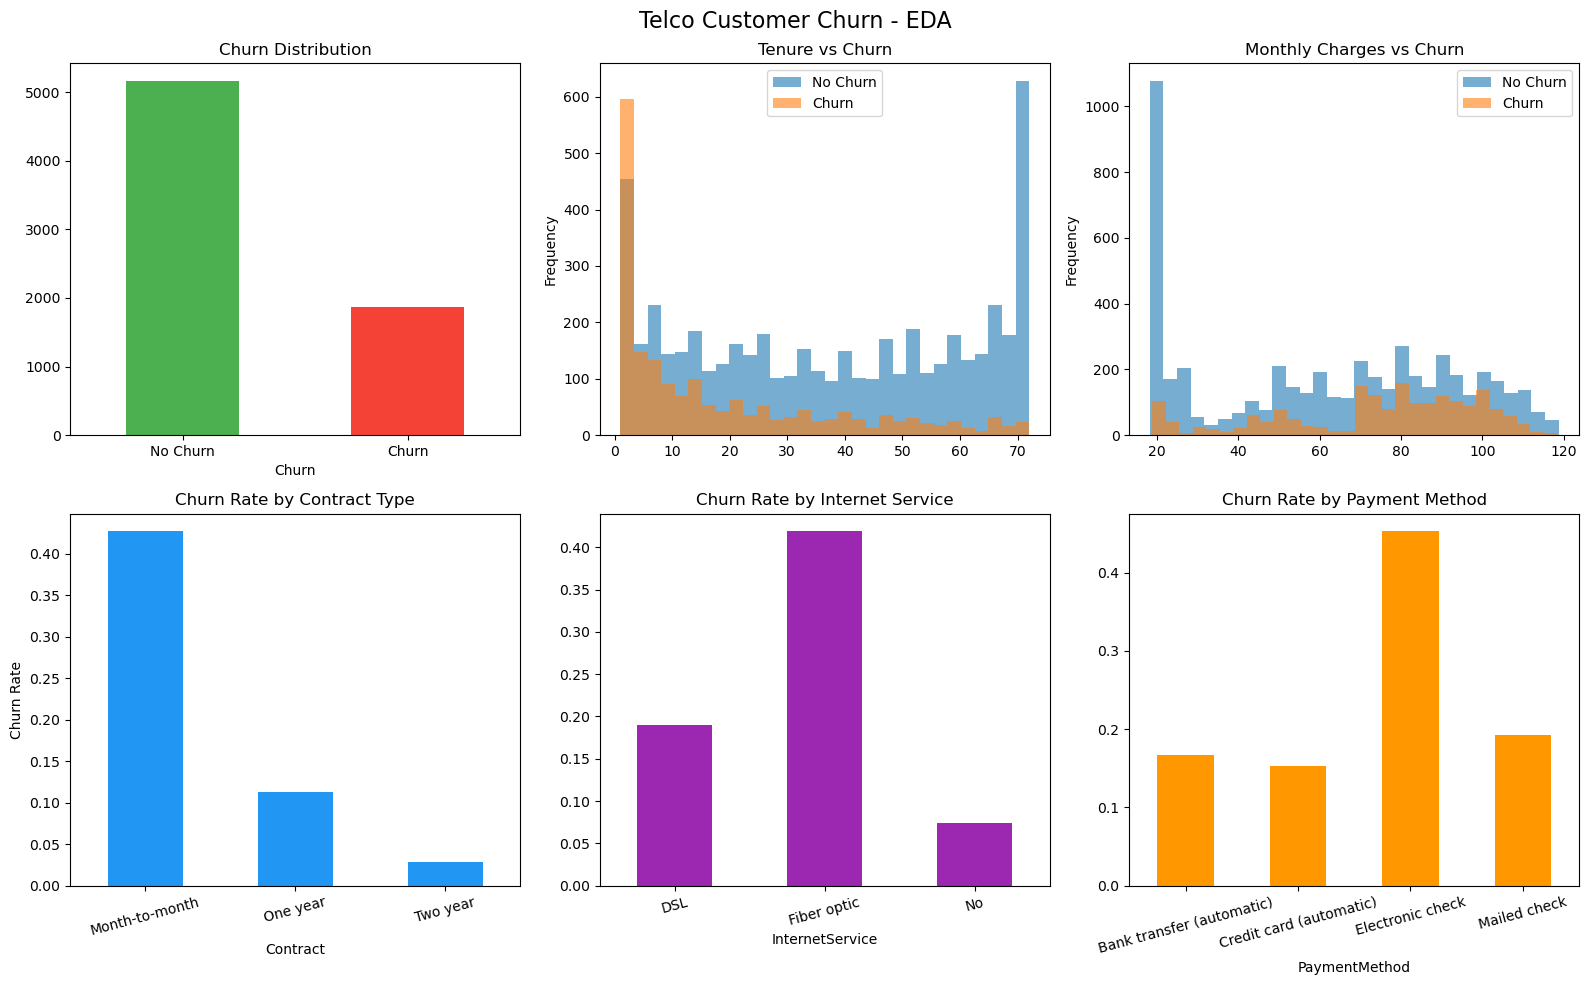

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telco Customer Churn - EDA', fontsize=16)

df['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4CAF50','#F44336'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

df.groupby('Churn')['tenure'].plot(kind='hist', ax=axes[0,1], alpha=0.6, bins=30, legend=True)
axes[0,1].set_title('Tenure vs Churn')
axes[0,1].legend(['No Churn', 'Churn'])

df.groupby('Churn')['MonthlyCharges'].plot(kind='hist', ax=axes[0,2], alpha=0.6, bins=30, legend=True)
axes[0,2].set_title('Monthly Charges vs Churn')
axes[0,2].legend(['No Churn', 'Churn'])

contract_churn = df.groupby('Contract')['Churn'].mean()
contract_churn.plot(kind='bar', ax=axes[1,0], color='#2196F3')
axes[1,0].set_title('Churn Rate by Contract Type')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].tick_params(axis='x', rotation=15)

internet_churn = df.groupby('InternetService')['Churn'].mean()
internet_churn.plot(kind='bar', ax=axes[1,1], color='#9C27B0')
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].tick_params(axis='x', rotation=15)

payment_churn = df.groupby('PaymentMethod')['Churn'].mean()
payment_churn.plot(kind='bar', ax=axes[1,2], color='#FF9800')
axes[1,2].set_title('Churn Rate by Payment Method')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8312


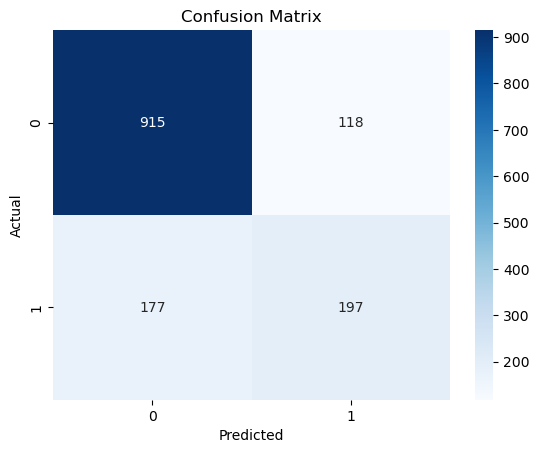

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

df.drop('customerID', axis=1, inplace=True)

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

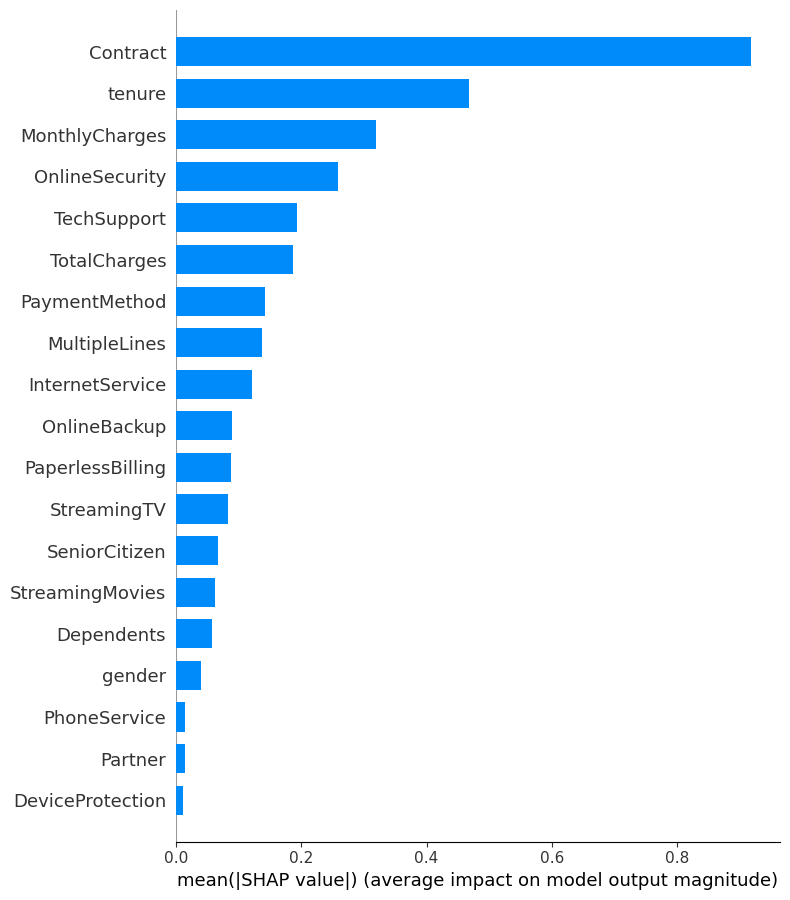

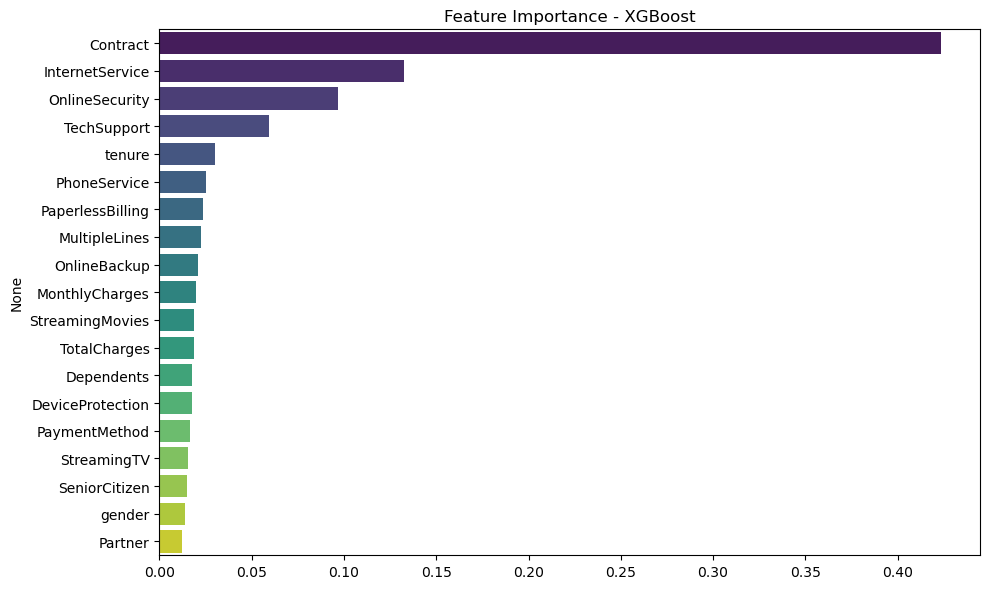

In [6]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [7]:
import joblib

joblib.dump(model, 'churn_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("Model saved!")

Model saved!
